# Bài kiểm tra thực hành — Lập trình phân tích dữ liệu · Buổi 1–5 · Đề số 02

**Họ và tên:** …………………………  
**MSSV:** …………  
**Lớp:** …………

> Đọc đề trong thư mục `de_thi/`. Làm mỗi câu trong đúng ô bên dưới — có thể thêm ô nếu cần.  
> Trước khi nộp: **Restart & Run All**, lưu file thành `MSSV_HoTen.ipynb`.

In [1]:
import re
import sqlite3
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path('../du_lieu')   # Google Colab: tải 4 tập tin dữ liệu lên rồi đổi thành Path('.')
assert (DATA_DIR / 'chuyen_di.csv').exists(), 'Không tìm thấy dữ liệu — kiểm tra lại DATA_DIR'

## Phần A — Python thuần: tập tin văn bản, regex, hàm (2,0 điểm)
*Không dùng pandas và numpy trong phần này.*

### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex · đếm sự kiện theo trạm · ghi `dong_loi.txt`

In [2]:
# A1
MAU = re.compile(r'(\d{4}-\d{2}-\d{2}) (\d{2}:\d{2}) \| ((?:DN|HA)\d{2}) \| (X[DM]\d{3}) '
                 r'\| (MUON|TRA) \| pin=(\d{1,3})%')
hop_le, loi = [], []
with open(DATA_DIR/'nhat_ky_khoa_xe.txt', 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()
        if line.strip == " " or line.startswith('#'):
            continue
        mau = MAU.fullmatch(line)
        hop_le.append(line) if mau else loi.append(line)
with open(DATA_DIR/'dong_loi.txt', 'w', encoding='utf-8-sig') as file:
    file.write('\n'.join(loi) + '\n')
print('So dong hop le:', len(hop_le))
print('So dong loi:', len(loi))

print('So su kien cua tung tram:\n', Counter(MAU.fullmatch(d).group(3) for d in hop_le))

So dong hop le: 754
So dong loi: 60
So su kien cua tung tram:
 Counter({'HA01': 136, 'DN02': 135, 'DN01': 132, 'DN04': 122, 'DN03': 119, 'HA02': 110})


### A2 (1,0 đ) Hàm `ti_le_pin_yeu(cac_dong, nguong=20, toi_thieu=8)` · xe có sự kiện ở cả hai thành phố

In [3]:
# A2
from collections import defaultdict
def ti_le_pin_yeu(cac_dong, nguong=20, toi_thieu=8):
    so_lan_tra_pin = defaultdict(int)
    tong_so_lan = defaultdict(int)
    for line in cac_dong:
        _, _,_, xe, sk, pin = MAU.fullmatch(line).groups()
        if sk != 'TRA':
            continue
        tong_so_lan[xe] +=1
        if float(pin) < nguong:
            so_lan_tra_pin[xe] +=1
    return {xe: so_lan_tra_pin[xe] / n for xe, n in tong_so_lan.items() if n >= toi_thieu}
ket_qua = ti_le_pin_yeu(hop_le)
if ket_qua:
    for xe in sorted(ket_qua):
        print(f'{xe}: {ket_qua[xe]:.3f}')
print('Xe co ti le pin yeu cao nhat:', max(ket_qua, key=ket_qua.get) )

xe_sk = {}
for d in hop_le:
    _, _, tram, xe, sk, _ = MAU.fullmatch(d).groups()
    xe_sk.setdefault(xe, set()).add(tram[:2])
print('Xe co su kien o ca 2 thanh pho:', sorted(xe for xe, sk in xe_sk.items() if len(sk) == 2))


XD001: 0.118
XD002: 0.062
XD003: 0.211
XD004: 0.231
XD005: 0.077
XD006: 0.062
XD007: 0.318
XD008: 0.000
XD009: 0.158
XD010: 0.053
XD011: 0.059
XD012: 0.250
XD013: 0.000
XD014: 0.214
XM001: 0.062
XM002: 0.167
XM003: 0.350
XM004: 0.100
XM005: 0.118
XM006: 0.133
XM007: 0.000
XM008: 0.167
XM009: 0.250
Xe co ti le pin yeu cao nhat: XM003
Xe co su kien o ca 2 thanh pho: ['XD004', 'XD012', 'XM008', 'XM010']


**Trả lời A2:** Xe có tỉ lệ pin yếu cao nhất là … ; các xe có sự kiện ở cả Đà Nẵng và Hội An: …

## Phần B — NumPy & lập trình hướng đối tượng (2,0 điểm)

### B1 (0,5 đ) Ma trận lượt thuê trạm × khung giờ

In [4]:
# B1
L = np.array([[42, 35, 28, 39, 71],
              [58, 31, 22, 34, 66],
              [25, 47, 44, 41, 52],
              [18, 26, 19, 23, 37],
              [12, 38, 41, 45, 83],
              [33, 29, 24, 36, 48]])
TRAM = ['DN01', 'DN02', 'DN03', 'DN04', 'HA01', 'HA02']
KHUNG = ['05–08h', '08–11h', '11–14h', '14–17h', '17–20h']
tong_luot = L.sum(axis=1,keepdims=True)
print('Tong luot thue cua tung tram:', tong_luot)
trung_binh = L.mean(axis=0).round(2)
print('Trung binh theo gio:',trung_binh)
print('Khung gio co trung binh cao nhat:', KHUNG[trung_binh.argmax()])

cao_diem = L[:, -2:]
print('Phan bo gio cao diem:\n', cao_diem)
ti_trong = (cao_diem / tong_luot * 100).round(2)
print('Ti trong gio cao diem\n', ti_trong)

peak = ti_trong[:, [0, 1]].sum(axis=1)
print('Cac tram co ti trong > 0.5:', np.array(TRAM)[peak > 0.5])

print('So o co luot thue > luot thue trung binh:', (L > trung_binh).sum())

Tong luot thue cua tung tram: [[215]
 [211]
 [209]
 [123]
 [219]
 [170]]
Trung binh theo gio: [31.33 34.33 29.67 36.33 59.5 ]
Khung gio co trung binh cao nhat: 17–20h
Phan bo gio cao diem:
 [[39 71]
 [34 66]
 [41 52]
 [23 37]
 [45 83]
 [36 48]]
Ti trong gio cao diem
 [[18.14 33.02]
 [16.11 31.28]
 [19.62 24.88]
 [18.7  30.08]
 [20.55 37.9 ]
 [21.18 28.24]]
Cac tram co ti trong > 0.5: ['DN01' 'DN02' 'DN03' 'DN04' 'HA01' 'HA02']
So o co luot thue > luot thue trung binh: 14


### B2 (0,5 đ) Giải hệ phương trình tìm bảng giá cước

In [5]:
# B2
a = np.array([[1,20,3], [1,35,8], [1,50,0]])
b = np.array([23, 42, 53])
nghiem = np.linalg.solve(a,b)
print('Ba tham so gia:', nghiem)

print('Kiem tra lai nghiem:', np.allclose(a @ nghiem, b))

du_doan = np.array([[1,30,6]])
print('Du doan gia cuoc:', du_doan @ nghiem)


Ba tham so gia: [-0.07692308  1.06153846  0.61538462]
Kiem tra lai nghiem: True
Du doan gia cuoc: [35.46153846]


### B3 (1,0 đ) Lớp `ChuyenDi` và `ChuyenDiGoiThang`

In [6]:
# B3
class ChuyenDi:
    def __init__(self, ma, phut, km, gia_phut, PHI_MO_KHOA=5000):
        self.ma = ma
        self.phut = phut
        self.km = km
        self.gia_phut = gia_phut
        self.PHI_MO_KHOA = PHI_MO_KHOA
    @property
    def phut(self):
        return self._phut
    @phut.setter
    def phut(self, value):
        if value <= 0:
            raise ValueError('Thoi luong khong duoc am')
        else:
            self._phut = value
    def cuoc_phi(self):
        return self.PHI_MO_KHOA + self.phut * self.gia_phut
    def toc_do_tb(self):
        return self.km / (self.phut / 60)
    def __str__(self):
        return f'{self.ma}: {self.phut} phút · {self.km} km · {round(self.toc_do_tb(),2)} km/h · cước {self.cuoc_phi():,} đ'

class ChuyenDiGoiThang(ChuyenDi):
    def __init__(self, ma, phut, km, gia_phut, phut_mien_phi = 30):
        super().__init__(ma, phut, km, gia_phut)
        self.phut_mien_phi = phut_mien_phi
    def cuoc_phi(self):
        return max(0, self.phut - self.phut_mien_phi) * self.gia_phut

print(ChuyenDi('CD001', 25, 6.0, 500))
print(ChuyenDiGoiThang('CD002', 48, 10.4, 500))

try:
    ChuyenDi('CD001', 0, 6.0, 500)
except ValueError:
    print('So phut phai lon hon 0')


CD001: 25 phút · 6.0 km · 14.4 km/h · cước 17,500 đ
CD002: 48 phút · 10.4 km · 13.0 km/h · cước 9,000 đ
So phut phai lon hon 0


## Phần C — Pandas: đọc, làm sạch, tích hợp (2,5 điểm)

### C1 (0,5 đ) Đọc CSV, Excel và SQLite

In [7]:
# C1
chuyen_di = pd.read_csv(DATA_DIR/'chuyen_di.csv')
chuyen_di['bat_dau'] = pd.to_datetime(chuyen_di['bat_dau'], format='%d/%m/%Y %H:%M')
chuyen_di['ket_thuc'] = pd.to_datetime(chuyen_di['ket_thuc'], format='%d/%m/%Y %H:%M')

khach_hang = pd.read_excel(DATA_DIR/'khach_hang.xlsx', sheet_name='khach_hang')
goi_cuoc = pd.read_excel(DATA_DIR/'khach_hang.xlsx', sheet_name='goi_cuoc')

with sqlite3.connect(DATA_DIR/'he_thong.db') as conn:
    tram = pd.read_sql('SELECT * from tram', conn)
    loai_xe = pd.read_sql('SELECT * from loai_xe', conn)

print('Kich thuoc bang chuyen di:', chuyen_di.shape)
print('Kich thuoc bang khach hang:', khach_hang.shape)
print('Kich thuoc bang goi cuoc:', goi_cuoc.shape)
print('Kich thuoc bang tram:',  tram.shape)
print('Kich thuoc bang loai xe:', loai_xe.shape)

print('So gia tri thieu cua cac cot trong bang chuyen di:\n', chuyen_di.isna().sum())

Kich thuoc bang chuyen di: (2635, 9)
Kich thuoc bang khach hang: (508, 5)
Kich thuoc bang goi cuoc: (3, 2)
Kich thuoc bang tram: (6, 4)
Kich thuoc bang loai xe: (3, 5)
So gia tri thieu cua cac cot trong bang chuyen di:
 ma_cd               0
bat_dau             0
ket_thuc           48
tram_muon           0
tram_tra            0
ma_kh             913
loai_xe             0
quang_duong_km     40
danh_gia          559
dtype: int64


### C2 (1,0 đ) Làm sạch bảng chuyến đi theo đúng 5 bước

In [8]:
# C2 — bước 1
chuyen_di = chuyen_di.drop_duplicates()
print('So dong con lai sau khi khu lap:', chuyen_di.shape)

So dong con lai sau khi khu lap: (2600, 9)


In [9]:
print(chuyen_di['loai_xe'].value_counts())

loai_xe
Xe đạp điện      793
Xe đạp           712
Xe máy điện      575
XE ĐẠP ĐIỆN       59
XE ĐẠP            56
Xe đạp điện       51
XE MÁY ĐIỆN       47
xe đạp            47
xe đạp điện       43
Xe dap            43
Xe may dien       43
xe máy điện       36
 Xe đạp           35
Xe dap dien       35
 Xe máy điện      25
Name: count, dtype: int64


In [10]:
# C2 — bước 2
xe_m = {'xe đạp': 'Xe đạp', 'xe dap': 'Xe đạp',                        # 2
              'xe đạp điện': 'Xe đạp điện', 'xe dap dien': 'Xe đạp điện',
              'xe máy điện': 'Xe máy điện', 'xe may dien': 'Xe máy điện'}
chuyen_di['loai_xe'] = chuyen_di['loai_xe'].str.strip().str.lower().map(xe_m)
print(chuyen_di['loai_xe'].value_counts())

loai_xe
Xe đạp điện    981
Xe đạp         893
Xe máy điện    726
Name: count, dtype: int64


In [11]:
# C2 — bước 3
chuyen_di['phut'] = (chuyen_di['ket_thuc'] - chuyen_di['bat_dau']).dt.total_seconds() / 60       # 3
so_am = (chuyen_di['phut'] <= 0).sum()
chuyen_di.loc[chuyen_di['phut'] <= 0, 'phut'] = np.nan
print('So gia tri bi doi thanh thieu:', so_am)
chuyen_di = chuyen_di[~(chuyen_di['phut'] < 2)]
chuyen_di.loc[(chuyen_di['quang_duong_km'] < 0) | (chuyen_di['quang_duong_km'] > 80)] = np.nan
print('So dong cua bang sau khi lam sach:', chuyen_di.shape[0])

So gia tri bi doi thanh thieu: 9
So dong cua bang sau khi lam sach: 2573


In [12]:
print(chuyen_di.columns.to_list())

['ma_cd', 'bat_dau', 'ket_thuc', 'tram_muon', 'tram_tra', 'ma_kh', 'loai_xe', 'quang_duong_km', 'danh_gia', 'phut']


In [13]:
q1 = chuyen_di.groupby('loai_xe')['phut'].transform(lambda s: s.quantile(0.25))     # 5
q3 = chuyen_di.groupby('loai_xe')['phut'].transform(lambda s: s.quantile(0.75))
tren = q3 + 1.5 * (q3 - q1)
ngoai_lai = chuyen_di['phut'] > tren
print('Ngoại lai theo loại xe:', chuyen_di.loc[ngoai_lai, 'loai_xe'].value_counts().to_dict())
print('Ngưỡng trên theo loại xe:', (chuyen_di.assign(tren=tren).groupby('loai_xe')['tren'].first()).round(2).to_dict())
median_cd = chuyen_di.groupby('loai_xe')['phut'].transform('median')
median_km = chuyen_di.groupby('loai_xe')['quang_duong_km'].transform('median')
chuyen_di['phut'] = chuyen_di['phut'].fillna(median_cd)
chuyen_di['quang_duong_km'] = chuyen_di['quang_duong_km'].fillna(median_km)
print('So chuyen theo tung loai xe:\n', chuyen_di['loai_xe'].value_counts())

Ngoại lai theo loại xe: {'Xe đạp điện': 37, 'Xe đạp': 31, 'Xe máy điện': 23}
Ngưỡng trên theo loại xe: {'Xe máy điện': 96.0, 'Xe đạp': 44.5, 'Xe đạp điện': 57.0}
So chuyen theo tung loai xe:
 loai_xe
Xe đạp điện    973
Xe đạp         876
Xe máy điện    713
Name: count, dtype: int64


### C3 (1,0 đ) Tích hợp bốn nguồn · tạo `df`

In [14]:
# C3
print('gia_30_phut co phai cot dan xuat khong?', np.allclose(loai_xe['phi_mo_khoa'] + 30 * loai_xe['gia_phut'], loai_xe['gia_30_phut']))
loai_xe = loai_xe.drop(columns='gia_30_phut')
print('So ma khach hang bi trung:', khach_hang['ma_kh'].duplicated().sum())
khach_hang = khach_hang.drop_duplicates(subset='ma_kh')


gia_30_phut co phai cot dan xuat khong? True
So ma khach hang bi trung: 8


In [15]:
khach_hang['so_dien_thoai'] = khach_hang['so_dien_thoai'].str.replace(r'\D', '', regex=True).str.replace(r'^84', '0', regex=True)
print(khach_hang['so_dien_thoai'])
print('So khach hang co so dien thoai ko du 10 so:', (khach_hang['so_dien_thoai'].str.len() != 10).sum())

ghep = pd.merge(khach_hang, goi_cuoc, on='goi_cuoc', how='left')
khong_co = chuyen_di[~chuyen_di['tram_muon'].isin(tram['id'])]
print('So dong bi loai:', len(khong_co))

df = chuyen_di.merge(loai_xe, left_on='loai_xe', right_on='ten_loai', how='left', validate='many_to_one').merge(ghep, on='ma_kh', how='left').merge(tram, left_on='tram_muon', right_on='id', validate='many_to_one')

df['goi_cuoc'] = df['goi_cuoc'].fillna('Khách lẻ')
df['giam_gia'] = df['giam_gia'].fillna(0)
df['cuoc'] = df['phi_mo_khoa'] + df['phut'] * df['gia_phut']
df['doanh_thu'] = df['cuoc'] * (1 - df['giam_gia'])
df.groupby('thanh_pho')['doanh_thu'].sum()
print(df.to_string())
print('So dong cua df:', df.shape[0])
print('So chuyen khach le:', (df['goi_cuoc'] == 'Khách lẻ').sum())
print(f'Tong doanh thu: {df['doanh_thu'].sum():,}')
print(f'Doanh thu theo thanh pho: {df.groupby('thanh_pho')['doanh_thu'].sum()}')
print('Doanh thu theo tram:', df.groupby('ten_tram')['doanh_thu'].sum())

0      0706363554
1      0937605362
2      0702262501
3      0775155524
4      0981461916
          ...    
503    0900385985
504    0901185204
505    0903014356
506    0385444057
507    0909733059
Name: so_dien_thoai, Length: 500, dtype: str
So khach hang co so dien thoai ko du 10 so: 9
So dong bi loai: 35
        ma_cd             bat_dau            ket_thuc tram_muon tram_tra   ma_kh      loai_xe  quang_duong_km            danh_gia   phut ma_loai     ten_loai  phi_mo_khoa  gia_phut  nam_sinh so_dien_thoai    goi_cuoc ngay_dang_ky  giam_gia    id  ten_tram thanh_pho  suc_chua      cuoc  doanh_thu
0     CD00001 2025-03-01 07:20:00 2025-03-01 08:05:00      DN01     DN03     NaN  Xe máy điện           14.60            Hài lòng   45.0      XM  Xe máy điện       8000.0    1000.0       NaN           NaN    Khách lẻ          NaT       0.0  DN01  Cầu Rồng   Đà Nẵng        30   53000.0    53000.0
1     CD00002 2025-03-01 08:57:00 2025-03-01 09:15:00      DN01     DN01     NaN  Xe đạp điện    

## Phần D — Biến đổi & thu gọn dữ liệu (1,5 điểm)

### D1 (0,75 đ) Mã hoá thứ bậc, biến đổi log, rời rạc hoá khung giờ, one-hot

In [16]:
# D1
import scipy.stats as scp
df = df.rename(columns={'danh_gia': 'diem_dg'})
danh_gia = {
    'Rất không hài lòng': 1,
    'Không hài lòng': 2,
    'Bình thường': 3,
    'Hài lòng': 4,
    'Không hài lòng': 5
}
df['diem_dg'] = df['diem_dg'].map(danh_gia)
print(df['diem_dg'])
df['log_phut'] = np.log1p(df['phut'])
print('Do lech cua phut truoc bien doi:', scp.skew(df['diem_dg'], nan_policy='omit').round(2))
print('Do lech cua phut sau bien doi:', scp.skew(df['log_phut'], nan_policy='omit').round(2))


0       4.0
1       4.0
2       3.0
3       3.0
4       4.0
       ... 
2533    4.0
2534    4.0
2535    NaN
2536    3.0
2537    3.0
Name: diem_dg, Length: 2538, dtype: float64
Do lech cua phut truoc bien doi: -0.05
Do lech cua phut sau bien doi: 0.13


In [ ]:
bins = [0, 9, 16, 20, 24]
df['khung_gio'] = pd.cut(df['bat_dau'].dt.hour, bins, labels=['Sáng', 'Trưa chiều', 'Tan tầm', 'Tối'], right=False)
print(df['khung_gio'])
print('So chuyen moi khung:\n', df['khung_gio'].value_counts())
ma_hoa = pd.get_dummies(df['khung_gio'], prefix='kg', dtype=int)
print(ma_hoa.columns)


0             Sáng
1             Sáng
2             Sáng
3       Trưa chiều
4       Trưa chiều
           ...    
2533    Trưa chiều
2534       Tan tầm
2535       Tan tầm
2536       Tan tầm
2537           Tối
Name: khung_gio, Length: 2538, dtype: category
Categories (4, str): ['Sáng' < 'Trưa chiều' < 'Tan tầm' < 'Tối']
So chuyen moi khung:
 khung_gio
Tan tầm       861
Trưa chiều    758
Sáng          715
Tối           204
Name: count, dtype: int64
Index(['kg_Sáng', 'kg_Trưa chiều', 'kg_Tan tầm', 'kg_Tối'], dtype='str')


### D2 (0,75 đ) Bảng đặc trưng khách hàng · tương quan · PCA

In [26]:
print(df.columns.to_list())

['ma_cd', 'bat_dau', 'ket_thuc', 'tram_muon', 'tram_tra', 'ma_kh', 'loai_xe', 'quang_duong_km', 'diem_dg', 'phut', 'ma_loai', 'ten_loai', 'phi_mo_khoa', 'gia_phut', 'nam_sinh', 'so_dien_thoai', 'goi_cuoc', 'ngay_dang_ky', 'giam_gia', 'id', 'ten_tram', 'thanh_pho', 'suc_chua', 'cuoc', 'doanh_thu', 'log_phut', 'khung_gio']


In [43]:
# D2
bo = df[df['goi_cuoc'] != 'Khách lẻ']
khach = bo.groupby('ma_kh').agg(
    so_chuyen = ('ma_cd', 'count'),
    tong_chi = ('doanh_thu', 'sum'),
    phut_tb = ('phut', 'mean'),
    km_tb = ('quang_duong_km', 'mean'),
    diem_tb = ('diem_dg', 'mean'),
    ti_le_xe_may = ('loai_xe', lambda x: (x == 'Xe máy điện').mean()),
)
khach['tong_chi'] = pd.qcut(khach['tong_chi'], q=4, labels=['Thấp', 'Trung bình', 'Khá', 'Cao'])
print(khach['tong_chi'].value_counts())

so = df.select_dtypes(include='number')
print('Cac cot so:', so.columns.to_list(), ',', 'so luong:', so.shape[1])
print('Correlation:', so.corr().to_string())

tong_chi
Thấp          119
Trung bình    118
Khá           118
Cao           118
Name: count, dtype: int64
Cac cot so: ['quang_duong_km', 'diem_dg', 'phut', 'phi_mo_khoa', 'gia_phut', 'nam_sinh', 'giam_gia', 'suc_chua', 'cuoc', 'doanh_thu', 'log_phut'] , so luong: 11
Correlation:                 quang_duong_km   diem_dg      phut  phi_mo_khoa  gia_phut  nam_sinh  giam_gia  suc_chua      cuoc  doanh_thu  log_phut
quang_duong_km        1.000000  0.002607  0.901785     0.658781  0.661209 -0.177376 -0.113415  0.012541  0.933198   0.931787  0.826871
diem_dg               0.002607  1.000000  0.009554     0.029895  0.030200 -0.011788 -0.080594  0.053111  0.002751   0.007218  0.030495
phut                  0.901785  0.009554  1.000000     0.468946  0.470185 -0.116267 -0.077333  0.001114  0.862430   0.858374  0.926045
phi_mo_khoa           0.658781  0.029895  0.468946     1.000000  0.999527 -0.232883 -0.140900  0.003637  0.787770   0.782367  0.497505
gia_phut              0.661209  0.030200  0.

**Trả lời D2:** Cặp đặc trưng dư thừa là … vì … ; PCA cần … thành phần để giữ ít nhất 90% phương sai.

## Phần E — Trực quan hoá (2,0 điểm)

/var/folders/wn/_4rdp5jj49g1nj7l8z3b20600000gn/T/ipykernel_79260/4119390558.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


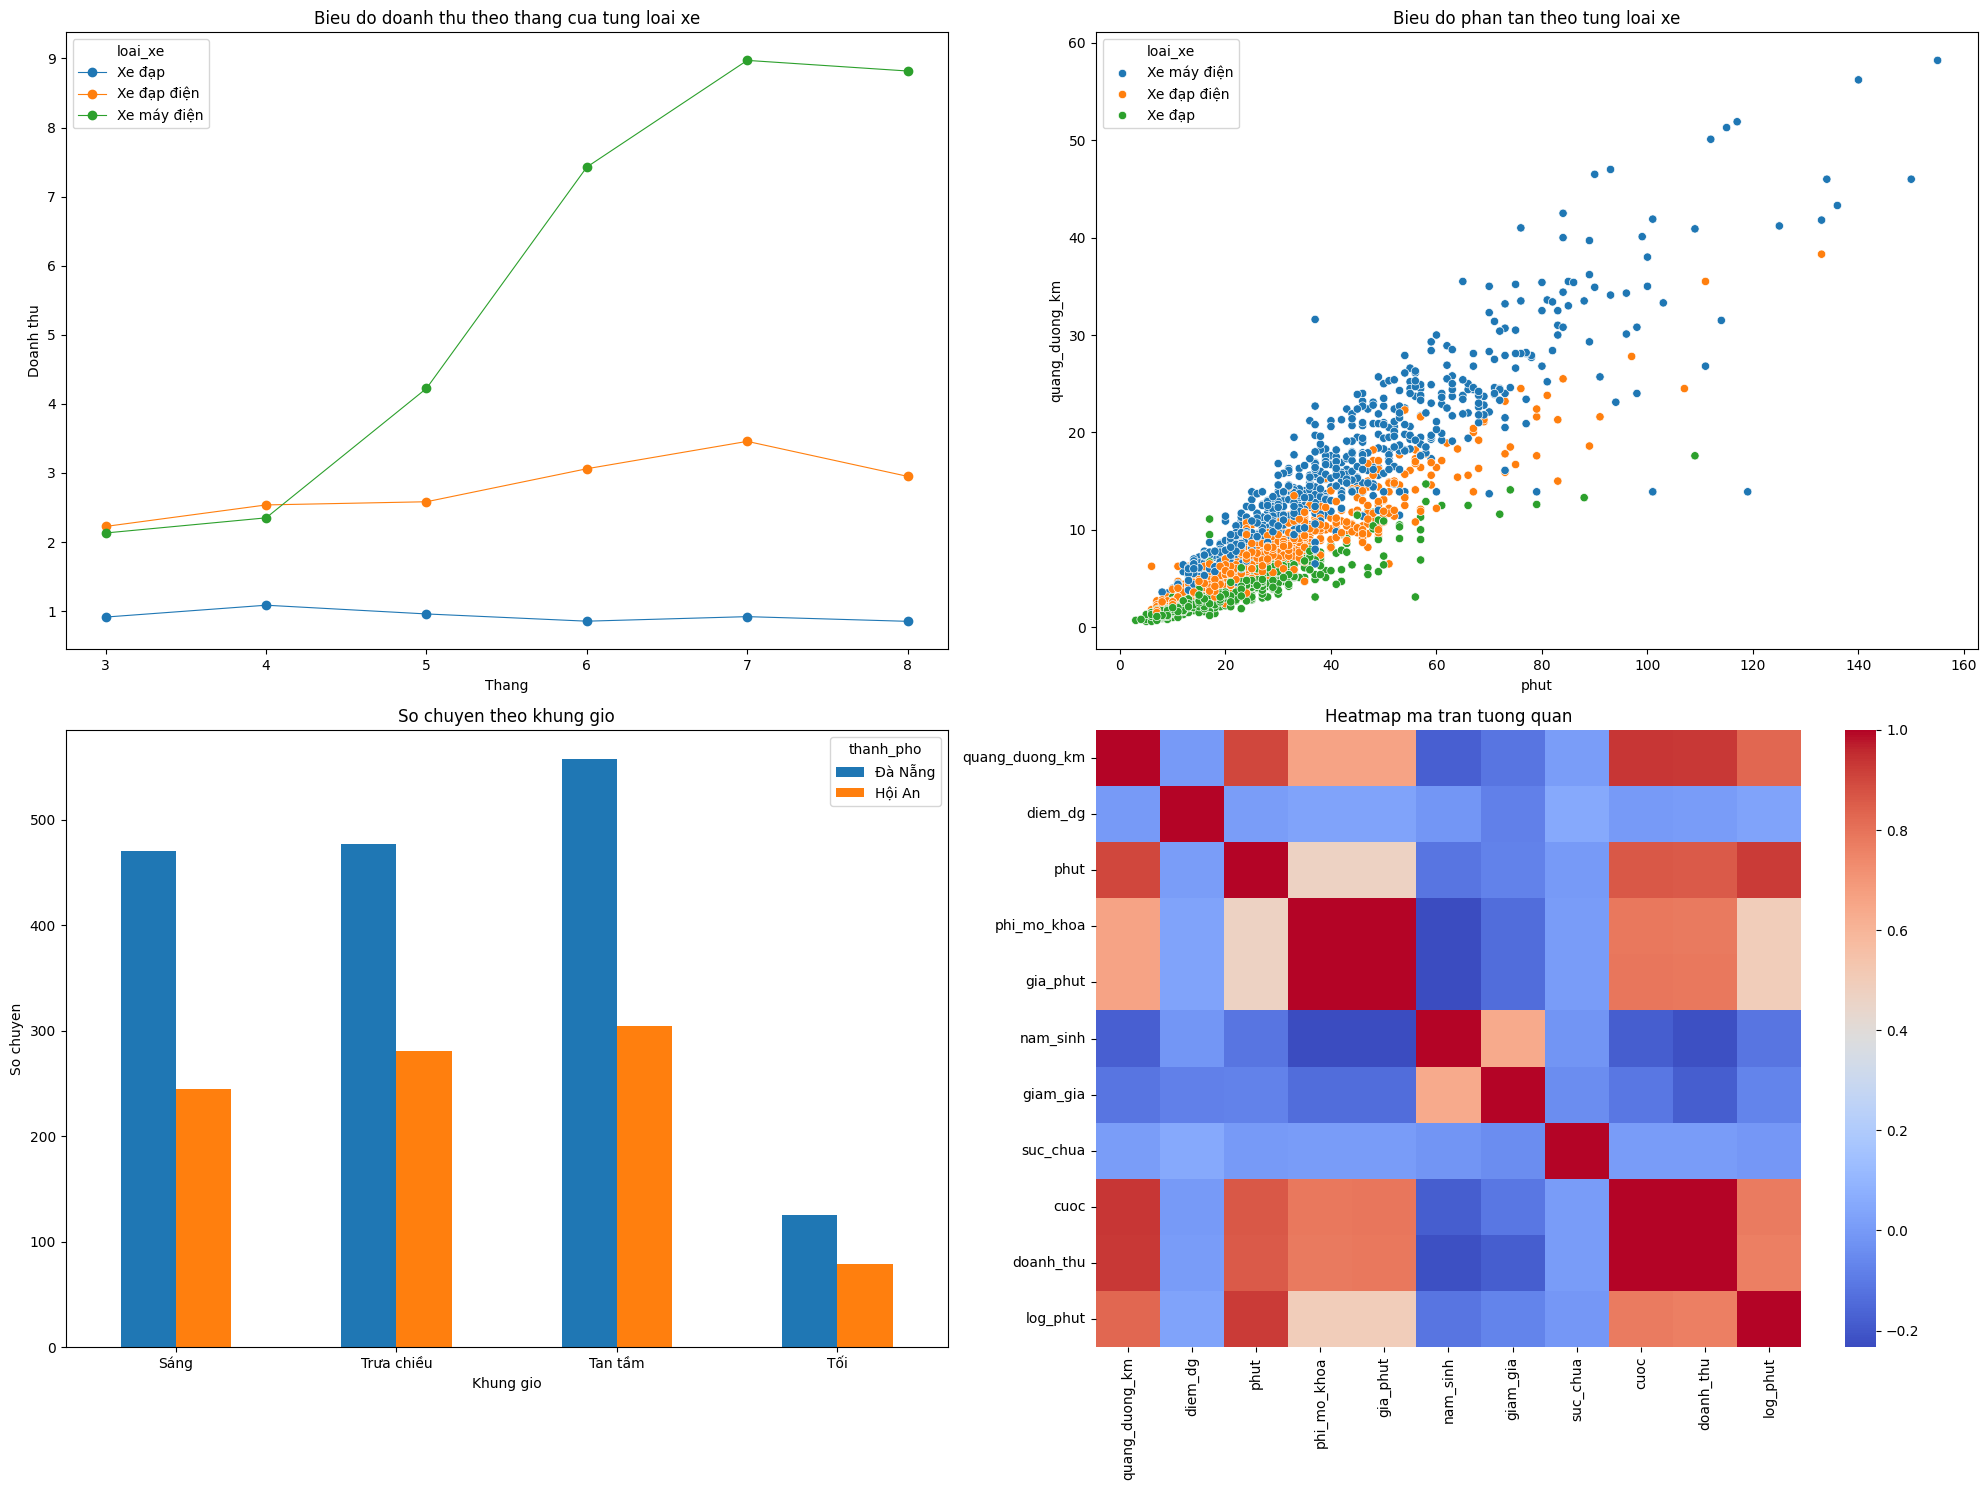

In [57]:
# E
fig, axes = plt.subplots(2,2, figsize=(20,15))
THU_TU_XE = ['Xe đạp', 'Xe đạp điện', 'Xe máy điện']
theo_thang = (df.groupby([df['bat_dau'].dt.month, 'loai_xe'])['doanh_thu'].sum() / 1e6).unstack()[THU_TU_XE]
theo_thang.plot(ax=axes[0,0], marker='o',  linewidth=0.8)
axes[0,0].set(title='Bieu do doanh thu theo thang cua tung loai xe', xlabel='Thang', ylabel='Doanh thu')

sns.scatterplot(data=df, x='phut', y='quang_duong_km',ax=axes[0,1], hue='loai_xe')
axes[0,1].set(title='Bieu do phan tan theo tung loai xe')

kg = pd.crosstab(df['khung_gio'], df['thanh_pho'])[['Đà Nẵng', 'Hội An']]
kg.plot(kind='bar', ax=axes[1, 0], rot=0)
axes[1,0].set(title='So chuyen theo khung gio', xlabel='Khung gio', ylabel='So chuyen')

sns.heatmap(so.corr(),ax=axes[1,1], cmap='coolwarm')
axes[1,1].set(title='Heatmap ma tran tuong quan')

fig.tight_layout()
fig.savefig('ket_qua.png', dpi=150)
fig.show()

**Nhận xét E:** (1) … (2) …